In [36]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
BASE_DIR = r"c:\Users\gulab\OneDrive\Documents\Desktop\Emotionrecognization"
TRAIN_DIR = os.path.join(BASE_DIR, 'Train') 
VAL_DIR = os.path.join(BASE_DIR, 'Test')


In [38]:
IMG_SIZE = 96 
BATCH_SIZE = 32
EPOCHS = 25 


In [39]:
print("Loading data...")
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=20,          # Increased augmentations
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

Loading data...


In [40]:
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [41]:
import glob
classes = sorted([os.path.basename(f).lower() for f in glob.glob(os.path.join(TRAIN_DIR, "*")) if os.path.isdir(f)])

In [42]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb", 
    class_mode='categorical',
    shuffle=True
)

Found 16108 images belonging to 8 classes.


In [43]:
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    class_mode='categorical',
    shuffle=False # Very important for confusion matrix!
)

Found 14518 images belonging to 8 classes.


In [44]:
num_classes = train_generator.num_classes
emotion_labels = list(train_generator.class_indices.keys())
print(f"Classes: {emotion_labels}")

Classes: ['anger', 'contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [45]:
print("Calculating class weights to balance dataset...")
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights_arr))
print(f"Class Weights: {class_weights}")

Calculating class weights to balance dataset...
Class Weights: {0: np.float64(1.3423333333333334), 1: np.float64(1.2915330339961513), 2: np.float64(1.6383238405207485), 3: np.float64(1.3316798941798942), 4: np.float64(0.8604700854700855), 5: np.float64(0.7300580130529369), 6: np.float64(0.6514073115496603), 7: np.float64(0.9502123643227938)}


In [46]:
print("Building the MobileNetV2 model...")
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), 
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = True
# Let's freeze all layers up to block_12 to retain foundational features
for layer in base_model.layers[:100]: 
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x) # L2 Regularization
x = Dropout(0.5)(x) # Dropout to reduce variance
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


Building the MobileNetV2 model...


In [47]:
METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]


In [48]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Lower learning rate since we are fine-tuning
    loss='categorical_crossentropy', 
    metrics=METRICS
)

In [49]:
checkpoint = ModelCheckpoint('emotion_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

callbacks = [checkpoint, early_stopping, reduce_lr]

In [50]:
print("Starting Transfer Learning & Fine-Tuning training...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights # Apply balanced class weights!
)

Starting Transfer Learning & Fine-Tuning training...


c:\Users\gulab\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
503/503 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.2740 - loss: 6.0399 - precision: 0.4366 - recall: 0.1209
Epoch 1: val_accuracy improved from None to 0.41039, saving model to emotion_model.keras
503/503 ━━━━━━━━━━━━━━━━━━━━ 389s 748ms/step - accuracy: 0.3395 - loss: 5.5131 - precision: 0.5543 - recall: 0.1693 - val_accuracy: 0.4104 - val_loss: 5.0886 - val_precision: 0.5483 - val_recall: 0.3015 - learning_rate: 1.0000e-04
Epoch 2/25
  1/503 ━━━━━━━━━━━━━━━━━━━━ 1:22 165ms/step - accuracy: 0.3125 - loss: 4.8590 - precision: 0.5000 - recall: 0.2500

c:\Users\gulab\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.41039
503/503 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - accuracy: 0.3125 - loss: 4.8590 - precision: 0.5000 - recall: 0.2500 - val_accuracy: 0.4083 - val_loss: 5.0907 - val_precision: 0.5430 - val_recall: 0.2996 - learning_rate: 1.0000e-04
Epoch 3/25
503/503 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.4560 - loss: 4.4513 - precision: 0.6712 - recall: 0.2693
Epoch 3: val_accuracy improved from 0.41039 to 0.44702, saving model to emotion_model.keras
503/503 ━━━━━━━━━━━━━━━━━━━━ 370s 737ms/step - accuracy: 0.4703 - loss: 4.2030 - precision: 0.6823 - recall: 0.2824 - val_accuracy: 0.4470 - val_loss: 4.2666 - val_precision: 0.5341 - val_recall: 0.3510 - learning_rate: 1.0000e-04
Epoch 4/25
  1/503 ━━━━━━━━━━━━━━━━━━━━ 1:41 203ms/step - accuracy: 0.4062 - loss: 4.1052 - precision: 0.5000 - recall: 0.2188
Epoch 4: val_accuracy did not improve from 0.44702
503/503 ━━━━━━━━━━━━━━━━━━━━ 56s 110ms/step - accuracy: 0.4062 - loss: 4.1052 - precision: 0.

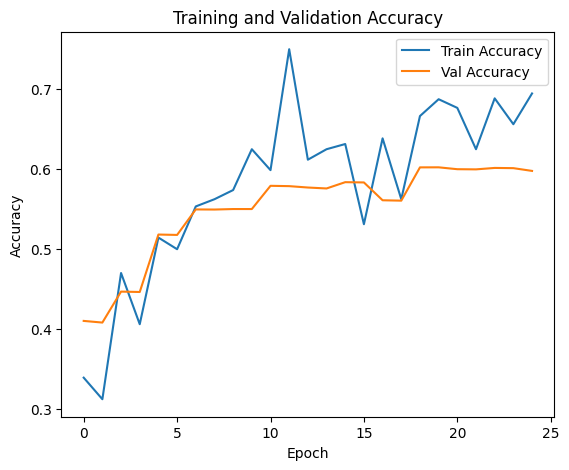

In [51]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

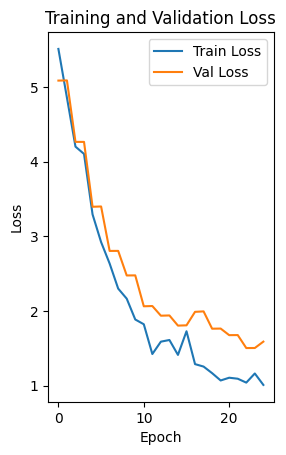

In [52]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [54]:
Y_pred = model.predict(
    val_generator,
    steps=int(np.ceil(val_generator.samples / BATCH_SIZE))
)

454/454 ━━━━━━━━━━━━━━━━━━━━ 71s 147ms/step


Saved confusion matrix as 'confusion_matrix.png'

Classification Report:
              precision    recall  f1-score   support

       anger       0.53      0.45      0.48      1718
    contempt       0.54      0.56      0.55      1312
     disgust       0.46      0.45      0.45      1248
        fear       0.53      0.46      0.49      1664
       happy       0.79      0.88      0.84      2704
     neutral       0.69      0.83      0.76      2368
         sad       0.58      0.49      0.53      1584
    surprise       0.42      0.40      0.41      1920

    accuracy                           0.60     14518
   macro avg       0.57      0.57      0.56     14518
weighted avg       0.59      0.60      0.59     14518



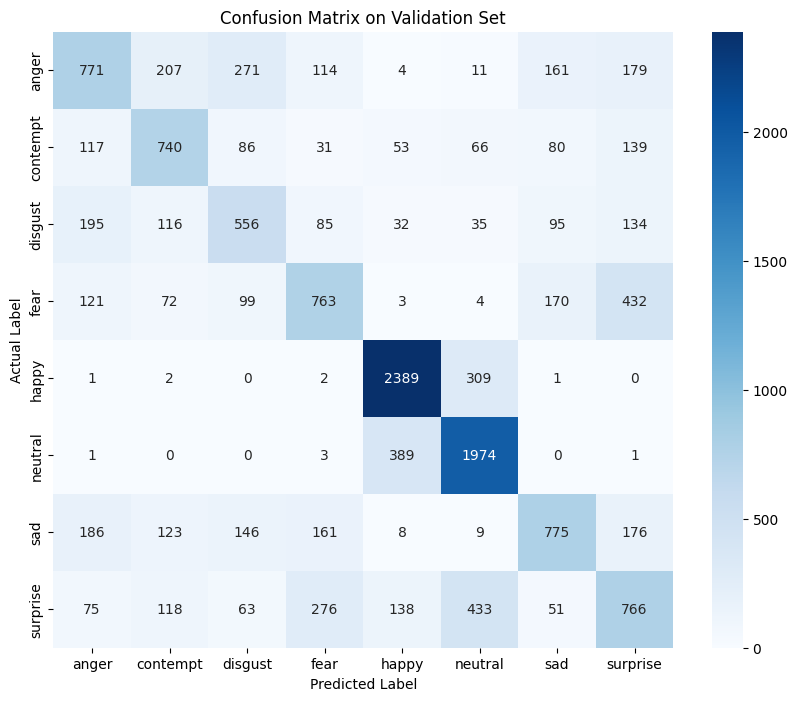

In [57]:
y_true = val_generator.classes
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotion_labels, yticklabels=emotion_labels, cmap='Blues')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix on Validation Set')
plt.savefig('confusion_matrix.png')
print("Saved confusion matrix as 'confusion_matrix.png'")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=emotion_labels))